In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
byol = pd.read_csv("runs/byol/metrics.csv")
simclr = pd.read_csv("runs/simclr/metrics.csv")
simsiam = pd.read_csv("runs/simsiam/metrics.csv")
simsiam_nosg = pd.read_csv("runs/simsiam_nosg/metrics.csv")
simsiam_nopred = pd.read_csv("runs/simsiam_nopred/metrics.csv")

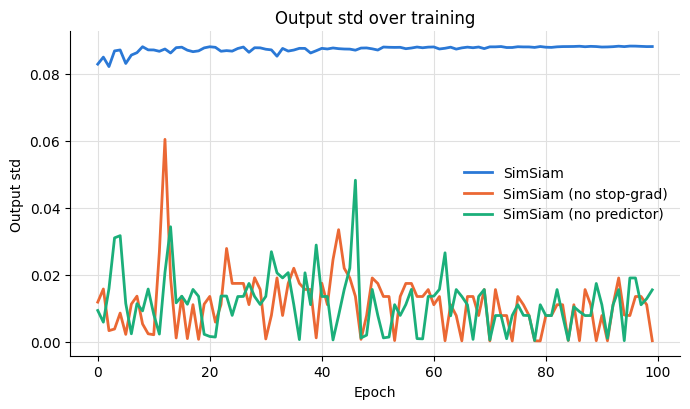

In [3]:
runs = {
    "SimSiam": simsiam,
    "SimSiam (no stop-grad)": simsiam_nosg,
    "SimSiam (no predictor)": simsiam_nopred,
}
colors = ["#2a78d6", "#eb6834", "#1baf7a"]

fig, ax = plt.subplots(figsize=(7, 4.2))
for (label, df), color in zip(runs.items(), colors):
    ax.plot(df["epoch"], df["output_std"], label=label, color=color, linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Output std")
ax.set_title("Output std over training")
ax.grid(True, color="#e0e0e0", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

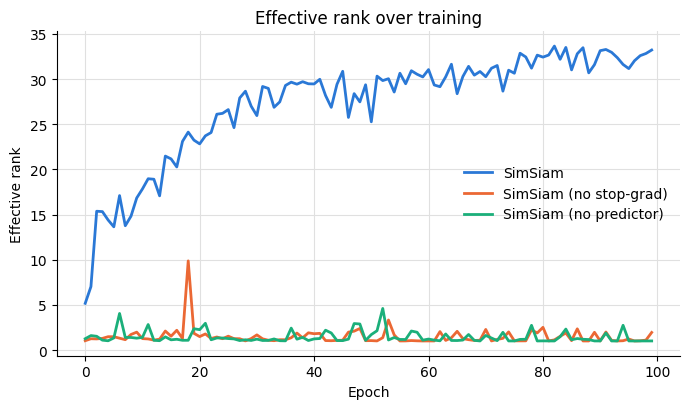

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for (label, df), color in zip(runs.items(), colors):
    ax.plot(df["epoch"], df["effective_rank"], label=label, color=color, linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Effective rank")
ax.set_title("Effective rank over training")
ax.grid(True, color="#e0e0e0", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

<>:38: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:38: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\aarus\AppData\Local\Temp\ipykernel_3484\2761392586.py:38: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax.plot(sv, label=f"{label} (eff. rank = {er:.1f}, $\sigma_1$ = {sv[0]:.1f})", color=color, linewidth=2)
c:\Users\aarus\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


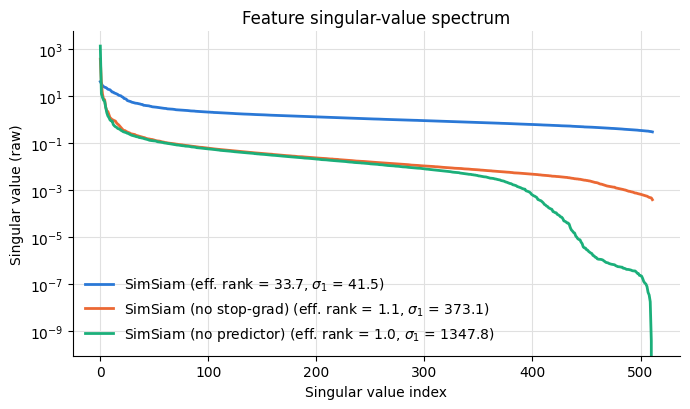

In [5]:
# Raw (un-normalized) singular-value spectra, recomputed from each run's encoder.pt.
# Mirrors diagnostics.py: one batch of 1024 SSL views -> encoder -> center -> svdvals,
# but skips the "sv / sv.max()" step so absolute feature scale is kept on the y-axis.
import os
import torch
from torch.utils.data import DataLoader
import data, metrics
from models import cifar_encoder

spectrum_runs = {
    "SimSiam": "runs/simsiam",
    "SimSiam (no stop-grad)": "runs/simsiam_nosg",
    "SimSiam (no predictor)": "runs/simsiam_nopred",
}

device = "cuda" if torch.cuda.is_available() else "cpu"
ds = data.get_ssl_dataset("./data", train=True)

def raw_singular_values(ckpt_path, batch=1024, seed=0):
    enc, _ = cifar_encoder()
    enc.load_state_dict(torch.load(ckpt_path, map_location=device)["encoder"])
    enc.to(device).eval()
    torch.manual_seed(seed)  # same images + augmentations for every run
    loader = DataLoader(ds, batch_size=batch, shuffle=True, num_workers=0, drop_last=True)
    (x1, _), _ = next(iter(loader))
    with torch.no_grad():
        f1 = enc(x1.to(device))
    er, sv = metrics.effective_rank(f1)
    return er, sv.numpy()

fig, ax = plt.subplots(figsize=(7, 4.2))
for (label, run_dir), color in zip(spectrum_runs.items(), colors):
    ckpt = os.path.join(run_dir, "encoder.pt")
    if not os.path.exists(ckpt):
        print(f"skipping {label}: {ckpt} not found")
        continue
    er, sv = raw_singular_values(ckpt)
    ax.plot(sv, label=f"{label} (eff. rank = {er:.1f}, $\sigma_1$ = {sv[0]:.1f})", color=color, linewidth=2)
ax.set_yscale("log")
ax.set_xlabel("Singular value index")
ax.set_ylabel("Singular value (raw)")
ax.set_title("Feature singular-value spectrum")
ax.grid(True, color="#e0e0e0", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
